In [9]:
# =========================================================
# Monthly Milk Production Forecasting
# Using RNN, LSTM, and GRU Deep Learning Models
# =========================================================

# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

from math import sqrt


In [10]:
# =========================
# 2. Load Dataset
# =========================

# Replace with your file path
df = pd.read_csv("monthly_milk_production.csv")

# Display first 5 rows
print(df.head())


      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727


In [11]:
# =========================
# 3. Data Preprocessing
# =========================

# Rename columns
df.columns = ['Month', 'Milk_Production']

# Convert Month column to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set Month as index
df.set_index('Month', inplace=True)

# Check dataset info
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Milk_Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None

Missing Values:
Milk_Production    0
dtype: int64


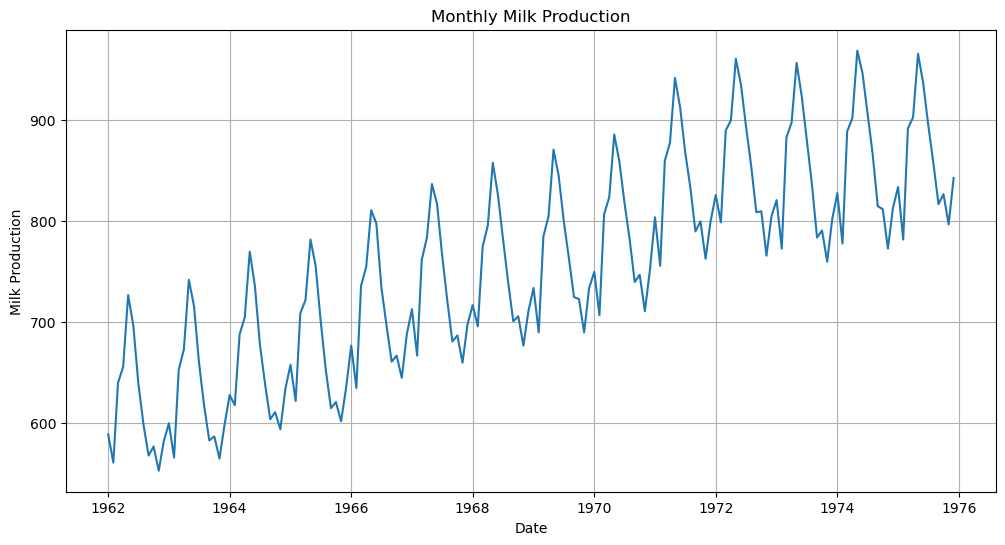

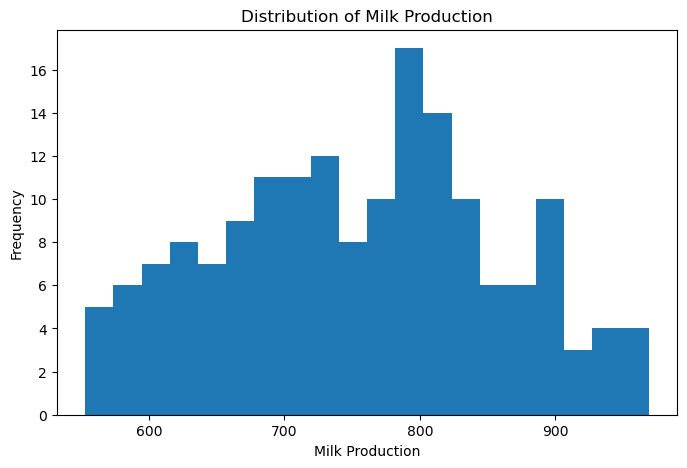

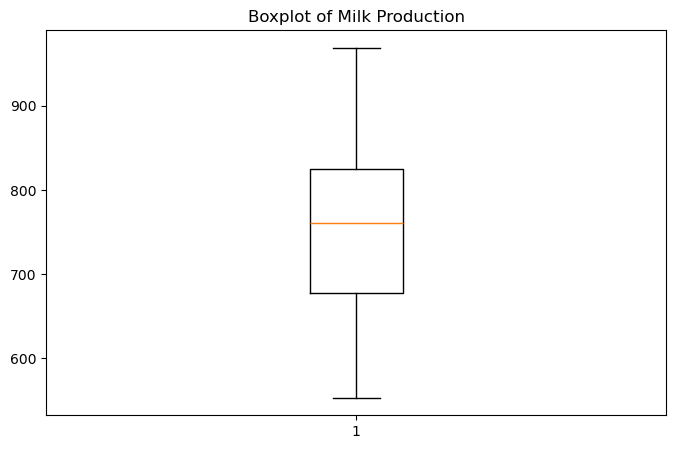

In [14]:
# =========================
# 4. Exploratory Data Analysis
# =========================

# Plot milk production trend
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Milk_Production'])
plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.grid(True)
plt.show()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['Milk_Production'], bins=20)
plt.title("Distribution of Milk Production")
plt.xlabel("Milk Production")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
plt.boxplot(df['Milk_Production'])
plt.title("Boxplot of Milk Production")
plt.show()

In [15]:
# =========================
# 5. Normalize Data
# =========================

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(df[['Milk_Production']])


In [16]:
# =========================
# 6. Create Time Sequences
# =========================

def create_sequences(data, window_size):
    
    X = []
    y = []
    
    for i in range(len(data) - window_size):
        
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
        
    return np.array(X), np.array(y)

window_size = 12

X, y = create_sequences(scaled_data, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (156, 12, 1)
y shape: (156, 1)


In [17]:
# =========================
# 7. Train-Test Split
# =========================

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)



Training Data Shape:
(124, 12, 1)

Testing Data Shape:
(32, 12, 1)


In [18]:
# =========================
# 8. Build RNN Model
# =========================

rnn_model = Sequential()

rnn_model.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(window_size,1)
))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# =========================
# 9. Train RNN Model
# =========================

early_stop = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0449
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0041
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020 
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0020
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017    
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017 
Epoch 16/50

In [20]:
# =========================
# 10. Build LSTM Model
# =========================

lstm_model = Sequential()

lstm_model.add(LSTM(
    units=50,
    activation='tanh',
    input_shape=(window_size,1)
))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# =========================
# 11. Train LSTM Model
# =========================

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0991
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0293
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0253 
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0245
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0250
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0237
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0237
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0219
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0221
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0204


In [22]:
# =========================
# 12. Build GRU Model
# =========================

gru_model = Sequential()

gru_model.add(GRU(
    units=50,
    activation='tanh',
    input_shape=(window_size,1)
))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.summary()


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                          │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# =========================
# 13. Train GRU Model
# =========================

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1534
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0368
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0285
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0265 
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0248
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0234
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0222
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0212
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0201
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0190


In [24]:
# =========================
# 14. Predictions
# =========================

rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

# Inverse Transform
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)

y_test_actual = scaler.inverse_transform(y_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


In [25]:
# =========================
# 15. Evaluation Metrics
# =========================

def evaluate_model(actual, predicted, model_name):
    
    mae = mean_absolute_error(actual, predicted)
    
    rmse = sqrt(mean_squared_error(actual, predicted))
    
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print(f"\n{model_name} Performance")
    print("-"*30)
    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("MAPE:", round(mape,2))

# RNN Evaluation
evaluate_model(y_test_actual, rnn_pred, "RNN")

# LSTM Evaluation
evaluate_model(y_test_actual, lstm_pred, "LSTM")

# GRU Evaluation
evaluate_model(y_test_actual, gru_pred, "GRU")



RNN Performance
------------------------------
MAE : 13.58
RMSE: 16.44
MAPE: 1.61

LSTM Performance
------------------------------
MAE : 61.41
RMSE: 68.49
MAPE: 7.22

GRU Performance
------------------------------
MAE : 83.72
RMSE: 105.14
MAPE: 9.32


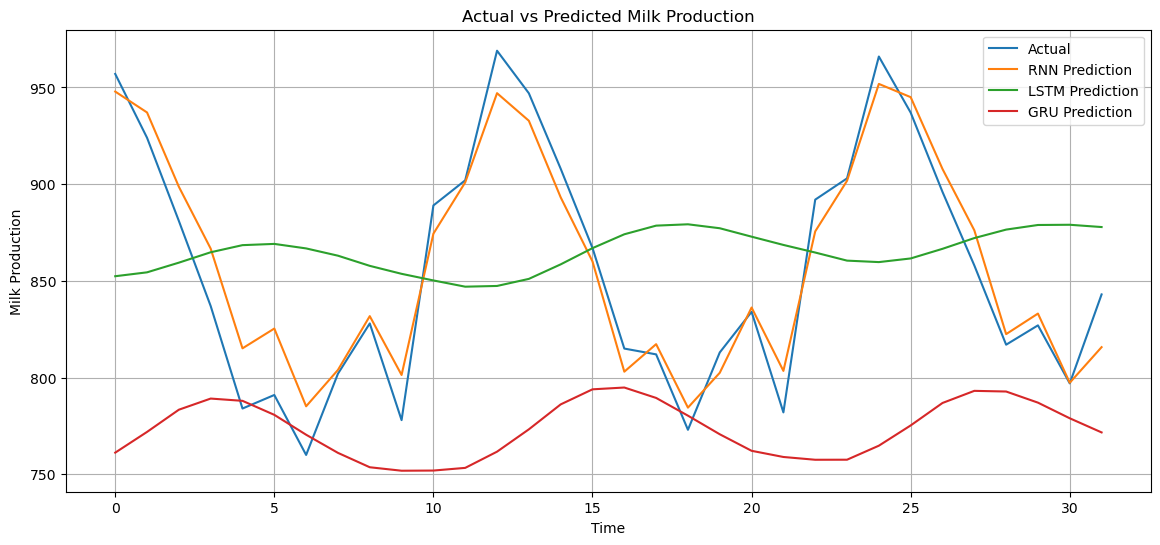

In [26]:
# =========================
# 16. Plot Predictions
# =========================

plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label='Actual')

plt.plot(rnn_pred, label='RNN Prediction')

plt.plot(lstm_pred, label='LSTM Prediction')

plt.plot(gru_pred, label='GRU Prediction')

plt.title("Actual vs Predicted Milk Production")

plt.xlabel("Time")

plt.ylabel("Milk Production")

plt.legend()

plt.grid(True)

plt.show()


In [27]:
# =========================
# 17. Compare Models
# =========================

results = pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'MAE':[
        mean_absolute_error(y_test_actual, rnn_pred),
        mean_absolute_error(y_test_actual, lstm_pred),
        mean_absolute_error(y_test_actual, gru_pred)
    ],
    'RMSE':[
        sqrt(mean_squared_error(y_test_actual, rnn_pred)),
        sqrt(mean_squared_error(y_test_actual, lstm_pred)),
        sqrt(mean_squared_error(y_test_actual, gru_pred))
    ]
})

print("\nModel Comparison")
print(results)



Model Comparison
  Model        MAE        RMSE
0   RNN  13.583611   16.441787
1  LSTM  61.412806   68.486729
2   GRU  83.717184  105.138834


In [28]:
# =========================
# 18. Select Best Model
# =========================

best_model_name = results.sort_values(by='RMSE').iloc[0]['Model']

print("\nBest Model:", best_model_name)

# Select Best Model
if best_model_name == 'RNN':
    best_model = rnn_model
    
elif best_model_name == 'LSTM':
    best_model = lstm_model
    
else:
    best_model = gru_model



Best Model: RNN


In [33]:
# =========================
# 19. Forecast Next 12 Months
# =========================

forecast_input = scaled_data[-window_size:]

forecast_input = forecast_input.reshape(1, window_size, 1)

future_predictions = []

for i in range(12):

    # Predict next value
    next_pred = best_model.predict(forecast_input, verbose=0)

    # Store prediction
    future_predictions.append(next_pred[0,0])

    # Reshape prediction to 3D
    next_pred_reshaped = next_pred.reshape(1,1,1)

    # Update input sequence
    forecast_input = np.concatenate(
        (forecast_input[:,1:,:], next_pred_reshaped),
        axis=1
    )

# Inverse transform predictions
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

# Create future dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Month': future_dates,
    'Forecasted_Milk_Production': future_predictions.flatten()
})

print("\n12-Month Forecast")
print(forecast_df)


12-Month Forecast
        Month  Forecasted_Milk_Production
0  1976-01-01                  846.623718
1  1976-02-01                  808.293762
2  1976-03-01                  882.885193
3  1976-04-01                  898.918396
4  1976-05-01                  947.971558
5  1976-06-01                  934.167480
6  1976-07-01                  903.148315
7  1976-08-01                  872.295227
8  1976-09-01                  830.848022
9  1976-10-01                  844.628784
10 1976-11-01                  818.000183
11 1976-12-01                  841.660828


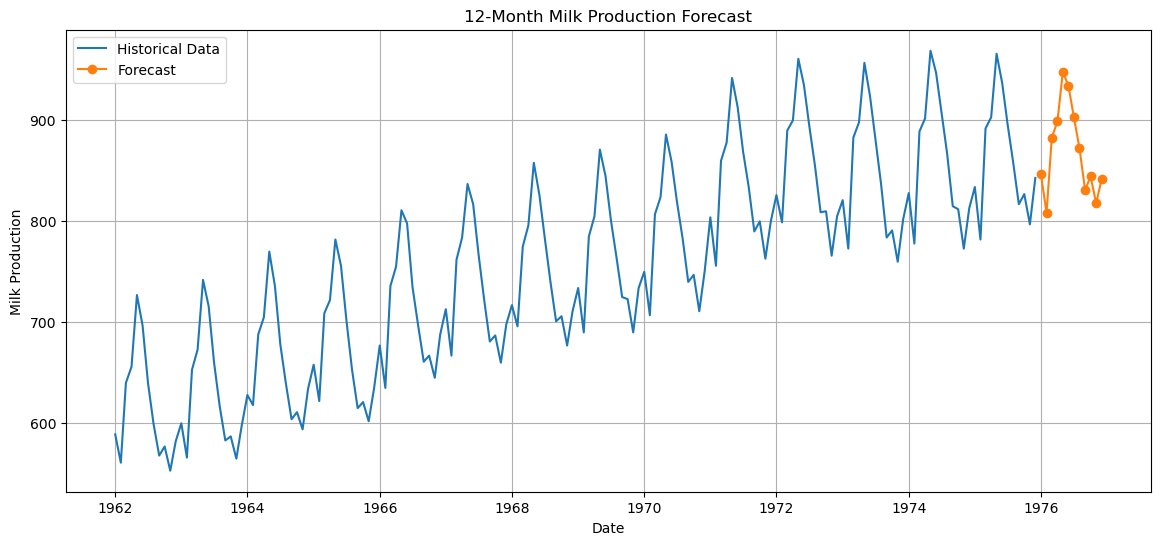

In [34]:
# =========================
# 20. Forecast Visualization
# =========================

plt.figure(figsize=(14,6))

# Historical data
plt.plot(
    df.index,
    df['Milk_Production'],
    label='Historical Data'
)

# Forecast data
plt.plot(
    future_dates,
    future_predictions.flatten(),
    label='Forecast',
    marker='o'
)

plt.title("12-Month Milk Production Forecast")

plt.xlabel("Date")

plt.ylabel("Milk Production")

plt.legend()

plt.grid(True)

plt.show()

In [35]:
# =========================
# 21. Save Forecast Results
# =========================
 
forecast_df.to_csv(
    "milk_production_forecast.csv",
    index=False
)

results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("\nFiles Saved Successfully!")


Files Saved Successfully!
